<img src="https://media.giphy.com/media/FSzLVme5Y3n3LMOiqP/giphy.gif" width="250" height="250"/>


Remember the rules of ~Fight~ Code Club:
1. ALWAYS DOCUMENT
2. Cite resources that you use (paste links)
3. Include the names people who you worked with
4. Be neat and organized

## Questions

With your own data that you collected:
1. Create 2 graphs between two variables. Be sure to include the title, labels of both axis. Include a legend if necessary. Be sure that nothing overlaps in the graph (words or legends, etc). 

2. Write 1-2 sentences that describe the main information presented and a conclusion that you could draw from that graph. 

3. Display the graphs side by side in one figure. 

4. Do a third graph that is not a line graph or bar chart (with proper labels and titles). Make sure this third graph displays different information than presented in step 1.



In [247]:
import matplotlib.pyplot as plt
import pandas as pd 
import seaborn as sns
#get my packages that Ill be using
graph_path= '/Users/alex/Documents/Pace/Classes/Junior/Spring/Data Analytics/Assignment 2/graphing-assignment-atuosto1'
graph_data=pd.read_csv(f'{graph_path}/RealFinalDF.csv')
#gets all of my data loaded here, this is the CSV from assignment 1
graph_data.columns

Index(['Week', 'Genre', 'index', 'Play Share', 'Play Share (Number)',
       'Total Plays', 'REC', 'UNRATE', 'PCE', 'UMICH', 'Year', 'Month'],
      dtype='object')

In [248]:
linegraph=graph_data[['Genre','Play Share','Year']]
linegraph

,Genre,Play Share,Year
0,Classical,0.001522,2005
1,Electronic,0.058125,2005
2,Hip Hop,0.017911,2005
3,Indie,0.025755,2005
4,Jazz,0.133868,2005
...,...,...,...
5043,folk,0.028571,2025
5044,other,0.828571,2025
5045,Pop,0.050000,2025
5046,other,0.950000,2025


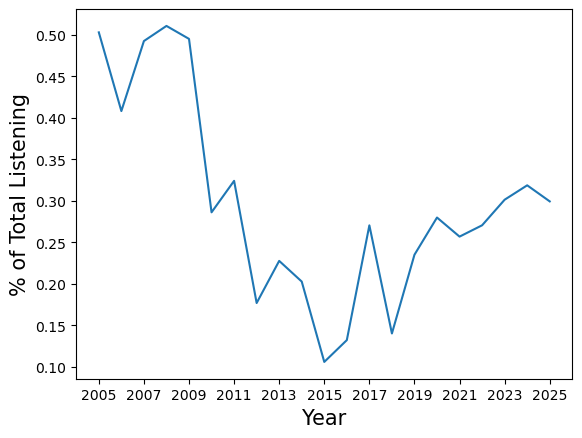

In [261]:
genres= linegraph['Genre'].unique()

rock=linegraph[linegraph['Genre']=='Rock']
groupedrock=rock.groupby('Year',as_index=False)['Play Share'].mean() #https://www.geeksforgeeks.org/pandas/python-pandas-dataframe-groupby/
#https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.groupby.html#:~:text=pandas.DataFrame.groupby-,DataFrame.,as%20a%20(single)%20key.
#just doing this for rock but I'll eventually make a for loop to get this for every single Genre
rockgraph=plt.plot(groupedrock['Year'],groupedrock['Play Share'])
plt.xticks([i for i in range(2005,2026,2)])
plt.xlabel('Year',fontsize=15)
plt.ylabel('% of Total Listening', fontsize=15)
plt.show()

In [ ]:
#https://www.geeksforgeeks.org/pandas/python-pandas-dataframe-groupby/
#https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.groupby.html#:~:text=pandas.DataFrame.groupby-,DataFrame.,as%20a%20(single)%20key.
#just doing this for rock but I'll eventually make a for loop to get this for every single Genre


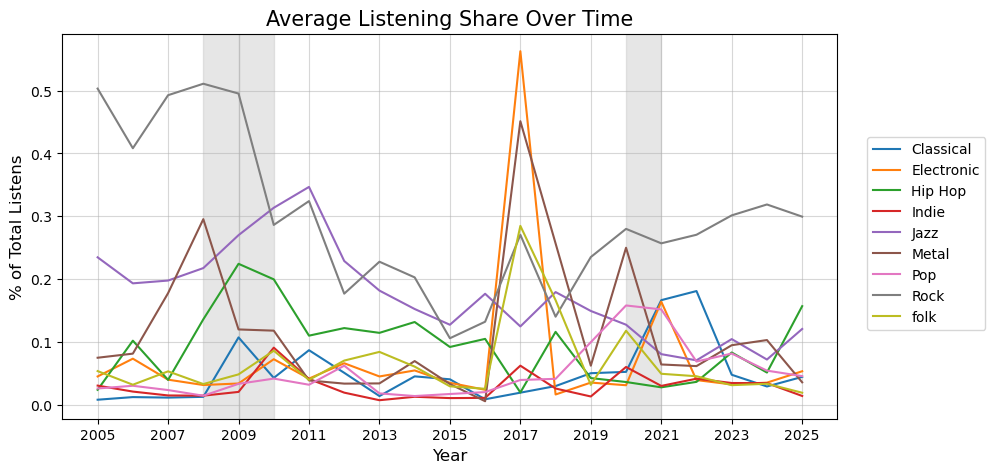

In [262]:
groupedgen=linegraph.groupby(['Genre','Year'],as_index=False)['Play Share'].mean() 
#https://www.geeksforgeeks.org/pandas/python-pandas-dataframe-groupby/
#https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.groupby.html#:~:text=pandas.DataFrame.groupby-,DataFrame.,as%20a%20(single)%20key.
#just doing this for rock but I'll eventually make a for loop to get this for every single Genre

# groups my top 4 genres by Genre and Year, False means that these won't become the index so i'm able to pull from them for the graph
groupedgen=groupedgen[groupedgen['Genre']!='other']
#excludes other from my data
plt.figure(figsize=(10,5))
#sets size to 10,5
lp=sns.lineplot(x='Year',y='Play Share',data=groupedgen, hue='Genre')
#actually gets my lineplot set up with an x of year, y of play share, data = my grouped, hue separates lines by genre, palette gets my colors
lp.set(xticks=([2005,2007,2009,2011,2013,2015,2017,2019,2021,2023,2025])) # plots my years, need to be in a list so there is a fixed number of years https://stackoverflow.com/questions/63723514/userwarning-fixedformatter-should-only-be-used-together-with-fixedlocator
lp.set_xlabel('Year',fontsize=12) #sets my x label, I'm using set_xlabel because set(xlabel) doesnt allow me to change the size https://stackoverflow.com/questions/36220829/fine-control-over-the-font-size-in-seaborn-plots
lp.set_ylabel('% of Total Listens',fontsize=12) #same as above but just for my y label
plt.title('Average Listening Share Over Time', fontsize=15) #makes the title with fontsize 17
recession=graph_data[graph_data['REC']==1]['Year'].unique() #gets the unique year for each of the recessions
for year in recession:
     plt.axvspan(year,year+1, color='#C2C2C2',alpha=0.4)
lp.legend(bbox_to_anchor=(1.2, 0.75), loc='upper right')
plt.grid(alpha=0.5)
plt.savefig(graph_path+'/SpaghettiGraph.png', dpi = 500, transparent=False,bbox_inches='tight') #https://stackoverflow.com/questions/9651092/my-matplotlib-pyplot-legend-is-being-cut-off
plt.show()

### Changing this to be a better spaghetti graph

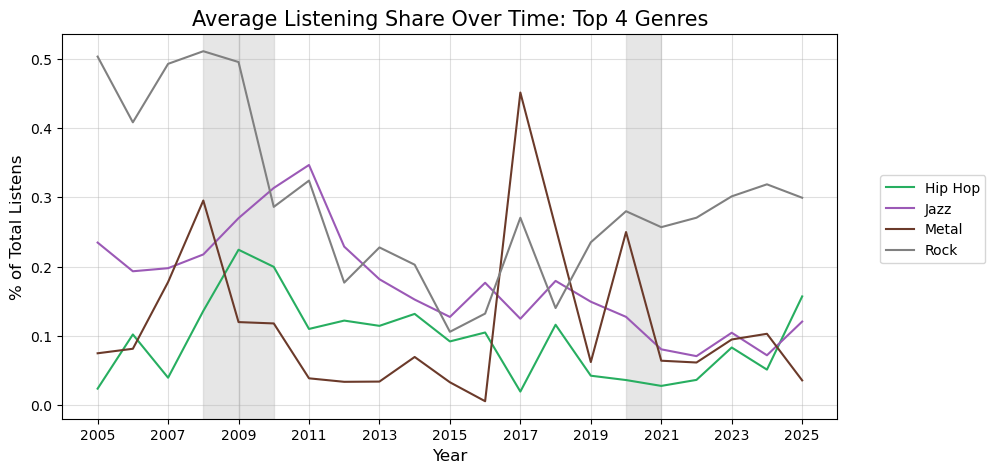

In [263]:
plt.figure(figsize=(10,5))
#sets the size of the figure I'm using
top4= linegraph[(linegraph['Genre']=='Rock')|(linegraph['Genre']=='Jazz')|
    (linegraph['Genre']=='Metal')|(linegraph['Genre']=='Hip Hop')] 
# get each of the top 4 genres
grouped4=top4.groupby(['Genre','Year'],as_index=False)['Play Share'].mean() 
# groups my top 4 genres by Genre and Year, False means that these won't become the index so i'm able to pull from them for the graph
colors={'Rock':'#808080','Jazz':'#9B59B6', 'Metal':'#6B3A2A', 'Hip Hop':'#27AE60'} 
# sets my colors into a dictionary seaborn pulls from for the colors, I wanted to keep them the same as the other bad spaghetti graph
lp=sns.lineplot(x='Year',y='Play Share',data=grouped4, hue='Genre', palette=colors)
#actually gets my lineplot set up with an x of year, y of play share, data = my grouped, hue separates lines by genre, palette gets my colors
lp.set(xticks=([2005,2007,2009,2011,2013,2015,2017,2019,2021,2023,2025])) # plots my years, need to be in a list so there is a fixed number of years https://stackoverflow.com/questions/63723514/userwarning-fixedformatter-should-only-be-used-together-with-fixedlocator
lp.set_xlabel('Year',fontsize=12) #sets my x label, I'm using set_xlabel because set(xlabel) doesnt allow me to change the size https://stackoverflow.com/questions/36220829/fine-control-over-the-font-size-in-seaborn-plots
lp.set_ylabel('% of Total Listens',fontsize=12) #same as above but just for my y label
plt.title('Average Listening Share Over Time: Top 4 Genres', fontsize=15) #makes the title with fontsize 17
recession=graph_data[graph_data['REC']==1]['Year'].unique() #gets the unique year for each of the recessions
for year in recession:
     plt.axvspan(year,year+1, color='#C2C2C2',alpha=0.4)
lp.legend(bbox_to_anchor=(1.2, 0.65), loc='upper right')
plt.grid(alpha=0.4)
plt.savefig(graph_path+'/AveListeningShare.png', dpi = 500, transparent=False,bbox_inches='tight') 
plt.show()

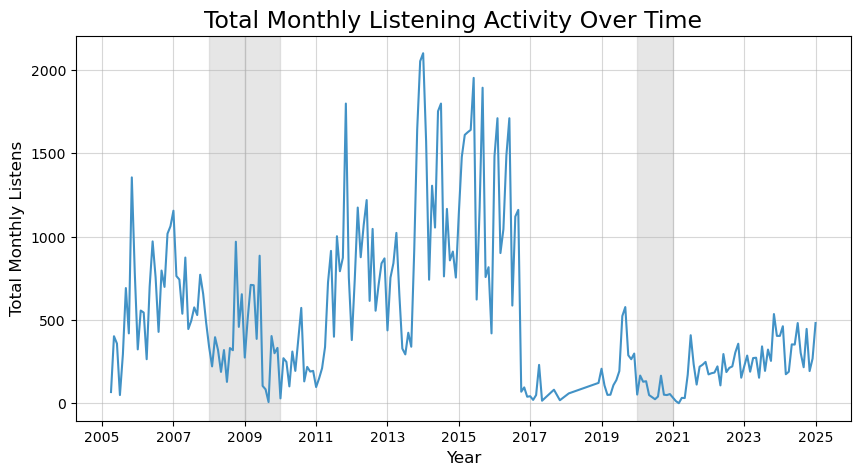

In [264]:
plays_monthly = graph_data.groupby(['Year', 'Month'])['Play Share (Number)'].sum().reset_index()#groups the data by year and month returning the sume of the play shares for each month 
clean=plays_monthly.drop_duplicates().reset_index() #cleaning my data for this graph
clean=clean[(clean['Year']!=2005)|(clean['Month']!=2)] #excludes february of 2005 as there was a huge outlier in this month
clean=clean[clean['Year']<2025] #matches the timeline of the data up with the previous graph
plt.figure(figsize=(10,5)) #creates the size for the charts
lp=sns.lineplot(x=clean['Year']+clean['Month']/12,y=clean['Play Share (Number)'],color='#4292C6') #https://stackoverflow.com/questions/48693316/find-then-convert-the-year-and-month-to-decimal#:~:text=First%20convert%20total%20years%20and,53%20/%2012%20=%204.41%20years.
#stuff above just gets the data to be in a decimal point instead of plotting once a year for the total plays, it was a gross ugly step function before
lp.set(xticks=([2005,2007,2009,2011,2013,2015,2017,2019,2021,2023,2025])) # plots my years, need to be in a list so there is a fixed number of years https://stackoverflow.com/questions/63723514/userwarning-fixedformatter-should-only-be-used-together-with-fixedlocator
lp.set_xlabel('Year',fontsize=12) #sets my x label, I'm using set_xlabel because set(xlabel) doesnt allow me to change the size https://stackoverflow.com/questions/36220829/fine-control-over-the-font-size-in-seaborn-plots
lp.set_ylabel('Total Monthly Listens',fontsize=12) #same as above but just for my y label
plt.title('Total Monthly Listening Activity Over Time', fontsize=17, horizontalalignment='center', x = 0.487)
recession=graph_data[graph_data['REC']==1]['Year'].unique() #gets the unique year for each of the recessions
for year in recession:
     plt.axvspan(year,year+1, color='#C2C2C2',alpha=0.4)
plt.grid(alpha=0.5)
plt.savefig(graph_path+'/MonthTotal.png', dpi = 500, transparent=False, bbox_inches='tight')
plt.show()

In [265]:
plays_monthly

,Year,Month,Play Share (Number)
0,2005,2,17384.0
1,2005,3,68.0
2,2005,4,403.0
3,2005,5,359.0
4,2005,6,50.0
...,...,...,...
229,2025,8,248.0
230,2025,9,127.0
231,2025,10,479.0
232,2025,11,387.0


### INTERPRETATION
##### These two line charts help to show the overall trend experienced by this use when examining listening patterns in music. 
##### We can see that there appears to be some kind of decline in listening during recessions even though this relationship may not be extremely accurate as during 2008's recession we can see a clearly volatile period.
##### My hypothesis that people will listen to more music during recessions is looking like it might not come out as statistically significant... unfortunately.

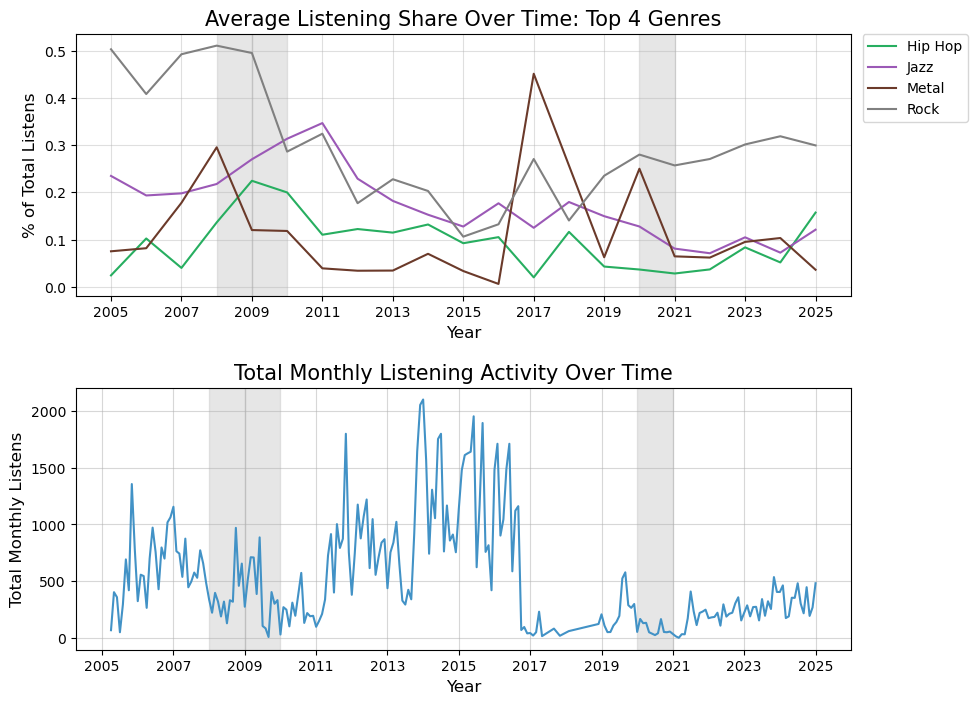

In [271]:

fig, ax = plt.subplots(nrows = 2, ncols = 1,figsize=(10,8))
 #creates the size for the chartsgrouped4=top4.groupby(['Genre','Year'],as_index=False)['Play Share'].mean() 

colors={'Rock':'#808080','Jazz':'#9B59B6', 'Metal':'#6B3A2A', 'Hip Hop':'#27AE60'} 
# sets my colors into a dictionary seaborn pulls from for the colors, I wanted to keep them the same as the other bad spaghetti graph
ax1=sns.lineplot(x='Year',y='Play Share',data=grouped4, hue='Genre', palette=colors,ax=ax[0])
#actually gets my lineplot set up with an x of year, y of play share, data = my grouped, hue separates lines by genre, 
#palette gets my colors, ax makes it so that ax1 is plotting on the 0th subplot https://www.geeksforgeeks.org/python/how-to-create-subplots-in-seaborn/
ax1.set(xticks=([2005,2007,2009,2011,2013,2015,2017,2019,2021,2023,2025])) 
# plots my years, need to be in a list so there is a fixed number of years https://stackoverflow.com/questions/63723514/userwarning-fixedformatter-should-only-be-used-together-with-fixedlocator
ax1.set_xlabel('Year',fontsize=12) 
#sets my x label, I'm using set_xlabel because set(xlabel) doesnt allow me to change the size https://stackoverflow.com/questions/36220829/fine-control-over-the-font-size-in-seaborn-plots
ax1.set_ylabel('% of Total Listens',fontsize=12) 
#same as above but just for my y label
ax1.set_title('Average Listening Share Over Time: Top 4 Genres', fontsize=15) 
#makes the title with fontsize 17
recession=graph_data[graph_data['REC']==1]['Year'].unique() 
#gets the unique year for each of the recessions
ax1.legend(bbox_to_anchor=(1.16, 1.025), loc='upper right')
ax1.grid(alpha=0.4)

ax2=sns.lineplot(x=clean['Year']+clean['Month']/12,y=clean['Play Share (Number)'],color='#4292C6', ax=ax[1])
#difference between this and ax1 is that this one has ax=ax[1] this means that we're printing on the 1st subplot
ax2.set(xticks=([2005,2007,2009,2011,2013,2015,2017,2019,2021,2023,2025])) # plots my years, need to be in a list so there is a fixed number of years https://stackoverflow.com/questions/63723514/userwarning-fixedformatter-should-only-be-used-together-with-fixedlocator
ax2.set_xlabel('Year',fontsize=12) #sets my x label, I'm using set_xlabel because set(xlabel) doesnt allow me to change the size https://stackoverflow.com/questions/36220829/fine-control-over-the-font-size-in-seaborn-plots
ax2.set_ylabel('Total Monthly Listens',fontsize=12) #same as above but just for my y label
ax2.set_title('Total Monthly Listening Activity Over Time', fontsize=15, horizontalalignment='center', x = 0.487)
ax2.grid(alpha=0.5)
for year in recession:
     ax1.axvspan(year,year+1, color='#C2C2C2',alpha=0.4)
     ax2.axvspan(year,year+1, color='#C2C2C2',alpha=0.4)

plt.subplots_adjust(hspace=0.35)
plt.savefig(graph_path+'/2Graphs.png', dpi = 500, transparent=False,bbox_inches='tight')#https://stackoverflow.com/questions/9651092/my-matplotlib-pyplot-legend-is-being-cut-off
plt.show()



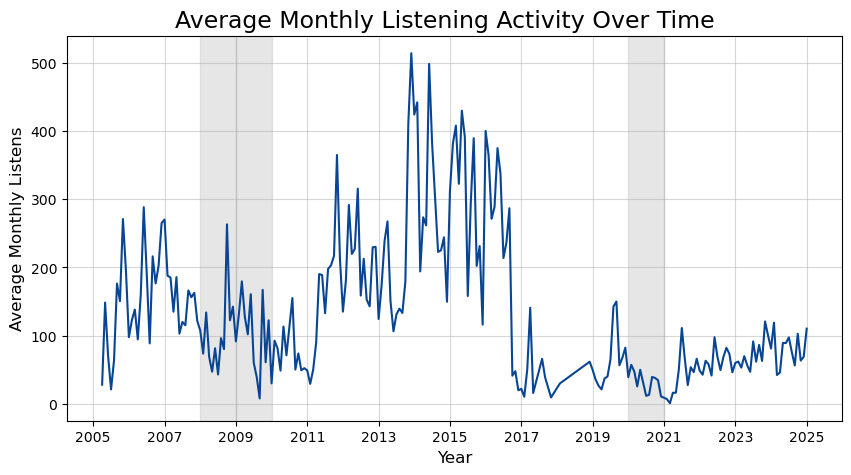

In [267]:
plays_monthly = graph_data.groupby(['Year', 'Month'])['Total Plays'].mean().reset_index()#groups the data by year and month returning the sume of the play shares for each month 
aveclean=plays_monthly.drop_duplicates().reset_index() #cleaning my data for this graph
aveclean=aveclean[(aveclean['Year']!=2005)|(aveclean['Month']!=2)] #excludes february of 2005 as there was a huge outlier in this month
aveclean=aveclean[aveclean['Year']<2025] #matches the timeline of the data up with the previous graph
plt.figure(figsize=(10,5)) #creates the size for the charts
lp=sns.lineplot(x=aveclean['Year']+aveclean['Month']/12,y=aveclean['Total Plays'],color='#084594') #https://stackoverflow.com/questions/48693316/find-then-convert-the-year-and-month-to-decimal#:~:text=First%20convert%20total%20years%20and,53%20/%2012%20=%204.41%20years.
#stuff above just gets the data to be in a decimal point instead of plotting once a year for the total plays, it was a gross ugly step function before
lp.set(xticks=([2005,2007,2009,2011,2013,2015,2017,2019,2021,2023,2025])) 
# plots my years, need to be in a list so there is a fixed number of years https://stackoverflow.com/questions/63723514/userwarning-fixedformatter-should-only-be-used-together-with-fixedlocator
lp.set_xlabel('Year',fontsize=12) 
#sets my x label, I'm using set_xlabel because set(xlabel) doesnt allow me to change the size https://stackoverflow.com/questions/36220829/fine-control-over-the-font-size-in-seaborn-plots
lp.set_ylabel('Average Monthly Listens',fontsize=12) 
#same as above but just for my y label
plt.title('Average Monthly Listening Activity Over Time', fontsize=17, horizontalalignment='center', x = 0.487)
#plots title
for year in recession:
     plt.axvspan(year,year+1, color='#C2C2C2',alpha=0.4)
plt.grid(alpha=0.5)
plt.savefig(graph_path+'/MeanMonthlyListen.png', dpi = 500, transparent=False, bbox_inches='tight')
plt.show()

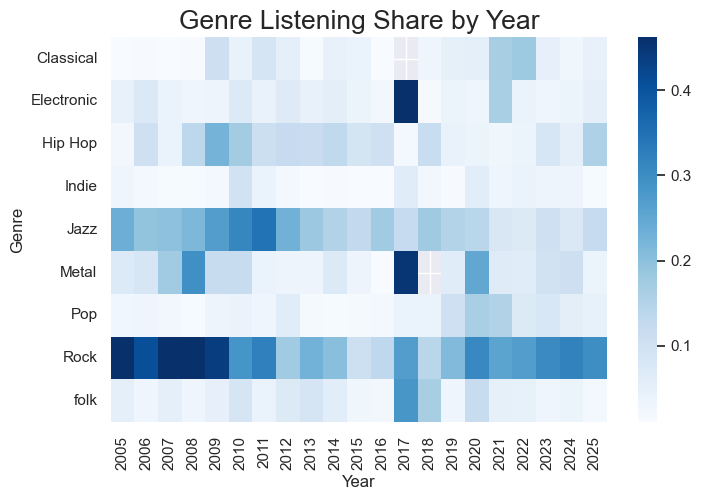

In [268]:
sns.set(font_scale=1)# sets the font size for the heatmap
plt.figure(figsize=(8,5))# makes the general blank figure
heatmap=linegraph[linegraph['Genre']!='other'] #makes the heatmap data the linegraph data as well
#just drops the other category
heatmapdata = heatmap[['Year','Genre', 'Play Share']].drop_duplicates() #puts all the data we need into one dataframe
hm = heatmapdata.pivot_table(index= 'Genre',columns = 'Year',values = 'Play Share',aggfunc='mean')
#I found this out at the links below, since I have 2 category variables this is considered a 3d pivot table
#that means I had to do the pivot table function instead of just pivot like we had in the lecture
#i also had to use the aggfunc which basically means that each of the index values will be the mean for each year for each Genre
#https://seaborn.pydata.org/generated/seaborn.heatmap.html
#https://stackoverflow.com/questions/69968235/pivot-table-in-proper-order-for-the-heatmap
#https://saturncloud.io/blog/pandas-pivot-table-list-of-aggfunc-a-guide/
plt.title('Genre Listening Share by Year', fontsize=19)
sns.heatmap(hm, cmap='Blues', robust= True) #gets my data, my continuous mapping, and looks at the robust percentiles (98th% and 2nd% true)
plt.savefig(graph_path+'/Heatmap.png', dpi = 500, transparent=False, bbox_inches='tight')
plt.show()


In [269]:
sns.reset_orig()
#this resets the seaborn theme because I nearly had a heart attack when I changed the theme and my other graphs changed
